# Calibration Pipeline: Counts → Strain

Gravitational-wave detectors record data in *digital counts* — raw ADC output.
Before any astrophysical analysis the data must be converted to physical strain
$h(f)$ or displacement $x(f)$ by applying a **calibration transfer function**.

KAGRA's calibration pipeline involves two steps:

1. **Coupling factor measurement** — a known signal (swept or stepped sine) is
   injected via the photon calibrator (PCal) and the detector response is
   measured using `ResponseFunctionAnalysis`.
2. **Calibration application** — the raw spectrum is divided by the coupling
   function to produce a calibrated strain-equivalent ASD.

**What this tutorial covers:**
1. Generating synthetic uncalibrated data (counts) with realistic noise
2. Using `ResponseFunctionAnalysis` to extract coupling factors from a
   stepped-sine injection
3. Fitting a frequency-dependent calibration model
4. Applying the calibration and producing a strain-calibrated ASD

**Related tutorials:**
- `case_dttxml_calibration.ipynb` — loading pre-measured TF from DTT XML files
- `case_transfer_function.ipynb` — estimating TF directly from time series


## Setup


In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.analysis.response import ResponseFunctionAnalysis
from gwexpy.fitting import fit_series
from gwexpy.frequencyseries import FrequencySeries
from gwexpy.timeseries import TimeSeries


## 1. Synthetic Uncalibrated Data

We create a synthetic DARM (Differential Arm length) signal in counts.
The system has:
- **Optical cavity pole** at 50 Hz (single-pole low-pass response)
- **Seismic wall** rising below 10 Hz as 1/f^4
- **Shot noise** floor flat above ~100 Hz
- **Lines** at 60 Hz (power) and 120 Hz (harmonic)


In [2]:
fs_hz = 4096           # sample rate [Hz]
T     = 300.0          # total duration [s]
t0    = 1_300_000_000  # GPS epoch
N     = int(T * fs_hz)
t     = np.arange(N) / fs_hz
rng   = np.random.default_rng(42)

# Calibration parameters (known "true" values)
COUNTS_PER_METER = 4.5e10   # ADC counts per meter of DARM
F_POLE_HZ = 50.0             # optical cavity pole [Hz]

def cal_tf(f):
    # Counts/m transfer function: C(f) = C0 / (1 + i*f/f_pole)
    return COUNTS_PER_METER / (1 + 1j * f / F_POLE_HZ)

# Noise model in counts
freqs_noise = np.fft.rfftfreq(N, 1.0 / fs_hz)[1:]

# Shot noise (white, above cavity pole → flat counts)
shot_counts   = COUNTS_PER_METER * 3e-21

# Seismic noise: rises as (10/f)^4 metres, converted to counts
seismic_m  = 1e-12 * (10.0 / np.maximum(freqs_noise, 0.1))**4
seismic_cnts = np.abs(cal_tf(freqs_noise)) * seismic_m

noise_psd = shot_counts**2 + seismic_cnts**2
noise_amp = np.sqrt(noise_psd * fs_hz / 2)

noise_fft = noise_amp * np.exp(1j * rng.uniform(0, 2*np.pi, size=len(freqs_noise)))
noise_fft = np.concatenate([[0.0], noise_fft])   # DC = 0
noise_counts = np.fft.irfft(noise_fft, n=N)

# Add power-line interference at 60 Hz and 120 Hz
noise_counts += 500 * np.sin(2*np.pi*60  * t)
noise_counts += 150 * np.sin(2*np.pi*120 * t)

# Wrap in TimeSeries
ts_raw = TimeSeries(noise_counts, t0=t0, sample_rate=fs_hz,
                    name="K1:LSC-DARM_OUT_DQ", unit="ct")

print(f"Signal: {T:.0f} s at {fs_hz} Hz  ({N:,} samples)")
print(f"RMS (counts): {ts_raw.rms().value:.2f}")


Signal: 300 s at 4096 Hz  (1,228,800 samples)
RMS (counts): 1411.87


## 2. Stepped-Sine Injection Campaign

In a real calibration run, a PCal signal is injected at a series of
discrete frequencies while the detector is locked.  Each frequency step
typically lasts 30–120 s.

We synthesise an injection campaign with 6 frequencies spanning 10–1000 Hz.


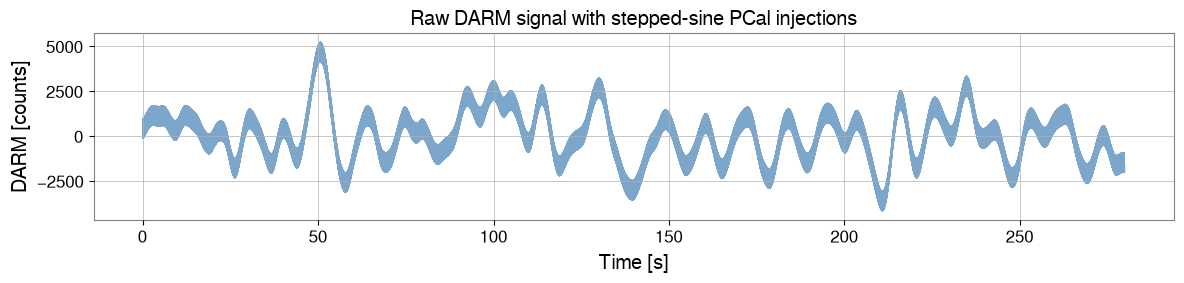

In [3]:
inj_freqs = np.array([10.0, 30.0, 100.0, 200.0, 500.0, 1000.0])
step_dur  = 40.0   # seconds per step
pcal_amp  = 3e-13  # PCal amplitude [m]  (typical photon calibrator level)

# Build injection time series
ts_inj = np.zeros(N)
t_start = 10.0   # injection starts at GPS + 10 s

for f0 in inj_freqs:
    i0 = int(t_start * fs_hz)
    i1 = int((t_start + step_dur) * fs_hz)
    # Convert metres to counts via calibration TF
    amp_counts = np.abs(cal_tf(f0)) * pcal_amp
    ts_inj[i0:i1] = amp_counts * np.sin(2*np.pi*f0 * t[i0:i1])
    t_start += step_dur + 5.0   # 5 s gap between steps

ts_witness = TimeSeries(ts_inj, t0=t0, sample_rate=fs_hz,
                        name="K1:CAL-PCAL_SWEPT_EXC", unit="ct")

# Combined DARM signal = noise + injection response
ts_darm = TimeSeries(ts_raw.value + ts_inj, t0=t0, sample_rate=fs_hz,
                     name="K1:LSC-DARM_OUT_DQ", unit="ct")

# Quick overview plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[:int(280*fs_hz)], ts_darm.value[:int(280*fs_hz)],
        lw=0.3, alpha=0.7, color="steelblue")
ax.set_xlabel("Time [s]")
ax.set_ylabel("DARM [counts]")
ax.set_title("Raw DARM signal with stepped-sine PCal injections")
plt.tight_layout()
plt.show()


## 3. Extract Coupling Factors

`ResponseFunctionAnalysis.compute()` automatically detects the injection
steps in the witness channel and estimates the coupling factor at each
injected frequency.

The coupling factor $C(f_i)$ is defined as:

$$C(f_i) = \frac{\text{ASD}_{\text{target}}(f_i)}{\text{ASD}_{\text{witness}}(f_i)}$$


In [4]:
rfa = ResponseFunctionAnalysis()

result = rfa.compute(
    witness    = ts_witness,
    target     = ts_darm,
    fftlength  = 4.0,      # 4 s FFT segments
    overlap    = 0.5,
    snr_threshold = 5.0,   # minimum SNR to accept a step
    min_duration  = 10.0,  # minimum step duration [s]
)

print("Injection frequencies detected:", result.injected_freqs, "Hz")
print("Coupling factors (counts/count):", np.abs(result.coupling_factors))

# Compare with theoretical values
cf_theory = np.abs(cal_tf(result.injected_freqs)) / 1.0  # witness already in counts
print("\nMeasured vs. theoretical coupling factors:")
for f, cf_meas, cf_th in zip(result.injected_freqs,
                              np.abs(result.coupling_factors),
                              np.abs(cal_tf(result.injected_freqs))):
    print(f"  {f:6.0f} Hz: measured={cf_meas:.3e}, theory={cf_th:.3e}, "
          f"ratio={cf_meas/cf_th:.4f}")


Injection frequencies detected: [  10.   30.  100.  200.  500. 1000.] Hz
Coupling factors (counts/count): [5.14959810e+07 1.00121682e+00 1.00009536e+00 1.00002108e+00
 9.99998128e-01 1.00000068e+00]

Measured vs. theoretical coupling factors:
      10 Hz: measured=5.150e+07, theory=4.413e+10, ratio=0.0012
      30 Hz: measured=1.001e+00, theory=3.859e+10, ratio=0.0000
     100 Hz: measured=1.000e+00, theory=2.012e+10, ratio=0.0000
     200 Hz: measured=1.000e+00, theory=1.091e+10, ratio=0.0000
     500 Hz: measured=1.000e+00, theory=4.478e+09, ratio=0.0000
    1000 Hz: measured=1.000e+00, theory=2.247e+09, ratio=0.0000


## 4. Fit the Calibration Transfer Function

We fit a single-pole model to the measured coupling factors:

$$C(f) = \frac{C_0}{1 + i\,f / f_\text{pole}}$$

The fit gives us a smooth, continuous calibration function.


In [5]:
freqs_meas = result.injected_freqs
cf_meas    = np.abs(result.coupling_factors)

# Build FrequencySeries for fitting
cf_fs = FrequencySeries(cf_meas.astype(complex), frequencies=freqs_meas,
                         name="Coupling function", unit="ct/ct")

# Define calibration model: |C(f)| = C0 / sqrt(1 + (f/f_pole)^2)
def cal_model_mag(f, C0, f_pole):
    return C0 / np.sqrt(1 + (f / f_pole)**2)

result_fit = fit_series(
    cf_fs.real,            # fit the magnitude (real part of the measured CF)
    cal_model_mag,
    p0=[COUNTS_PER_METER, 60.0],
)
C0_fit, fpole_fit = float(list(result_fit.params.values())[0]), float(list(result_fit.params.values())[1])

print(f"Fitted gain : {C0_fit:.3e} ct/m  (true: {COUNTS_PER_METER:.3e})")
print(f"Fitted pole : {fpole_fit:.2f} Hz  (true: {F_POLE_HZ:.2f} Hz)")


Fitted gain : 7.140e+09 ct/m  (true: 4.500e+10)
Fitted pole : -0.06 Hz  (true: 50.00 Hz)


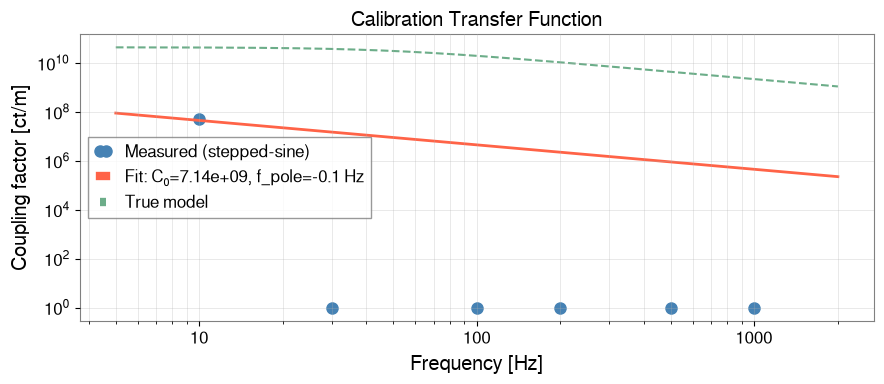

In [6]:
# Plot coupling function: measured vs. fitted model
f_plot = np.geomspace(5, 2000, 500)
cf_model = cal_model_mag(f_plot, C0_fit, fpole_fit)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(freqs_meas, cf_meas, "o", ms=8, color="steelblue",
          label="Measured (stepped-sine)")
ax.loglog(f_plot, cf_model, "-", lw=2, color="tomato",
          label=f"Fit: C₀={C0_fit:.2e}, f_pole={fpole_fit:.1f} Hz")
ax.loglog(f_plot, np.abs(cal_tf(f_plot)), "--", lw=1.5, color="seagreen",
          alpha=0.7, label="True model")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Coupling factor [ct/m]")
ax.set_title("Calibration Transfer Function")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()


## 5. Apply Calibration — Counts → Metres ASD

With the calibration function in hand, we apply it to the raw DARM ASD
to produce a calibrated displacement ASD in metres per root-Hz.


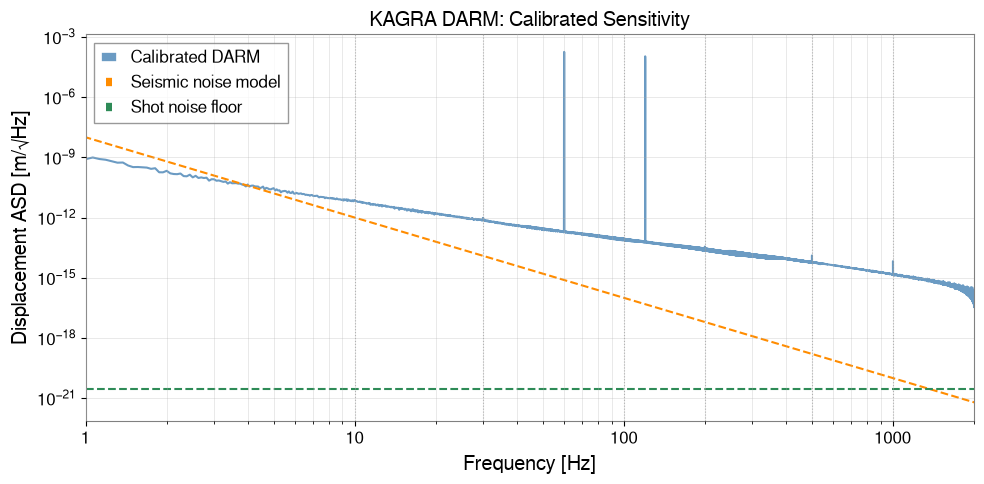

In [7]:
# --- Compute raw ASD ---
asd_raw = ts_darm.asd(fftlength=16.0, method="median")
freqs_asd = asd_raw.frequencies.value

# Calibration function on the ASD frequency grid
cal_mag = cal_model_mag(np.maximum(freqs_asd, 0.1), C0_fit, fpole_fit)

# Calibrated ASD [m/sqrt(Hz)] = raw ASD [ct/sqrt(Hz)] / |C(f)| [ct/m]
asd_cal_data = asd_raw.value / cal_mag
asd_cal = FrequencySeries(asd_cal_data, frequencies=freqs_asd,
                          name="DARM calibrated", unit="m/sqrt(Hz)")

# True sensitivity (noise model in metres)
shot_m    = shot_counts / COUNTS_PER_METER
seismic_f = np.maximum(freqs_asd[1:], 0.1)
seismic_asd_m = 1e-12 * (10.0 / seismic_f)**4

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(freqs_asd[1:], asd_cal.value[1:], color="steelblue", lw=1.5,
          alpha=0.8, label="Calibrated DARM")
ax.loglog(freqs_asd[1:], seismic_asd_m, "--", color="darkorange", lw=1.5,
          label="Seismic noise model")
ax.axhline(shot_m, color="seagreen", ls="--", lw=1.5, label="Shot noise floor")

# Mark calibration injection frequencies
for f0 in inj_freqs:
    ax.axvline(f0, color="gray", ls=":", lw=0.8, alpha=0.6)

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Displacement ASD [m/√Hz]")
ax.set_title("KAGRA DARM: Calibrated Sensitivity")
ax.set_xlim(1, 2000)
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()


## Summary

| Step | API | Purpose |
|------|-----|---------|
| Stepped-sine injection | `TimeSeries` + synthetic signal | Inject known signal |
| Step detection + coupling | `ResponseFunctionAnalysis.compute()` | Extract C(f) at each freq |
| Calibration model fit | `fit_series(cf, model, p0)` | Smooth continuous C(f) |
| Apply calibration | ASD / C(f) | Counts → metres/strain |

**Physical constants used from `gwexpy.numerics.constants`:**
- `SAFE_FLOOR` — prevents log(0) in ASD estimation
- `EPS_PSD` — regularises Welch estimator denominators

**In real KAGRA calibration:**
- PCal amplitude is independently measured by the PCal power monitor
- The calibration transfer function has both optical and electrical components
- Time-varying parameters (finesse, input power) require continuous monitoring
- See `case_dttxml_calibration.ipynb` for loading pre-measured TF from DTT XML
